In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import tree
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score 


In [41]:
df = sns.load_dataset('titanic')
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [42]:
df = df.drop(columns=['embarked','class','who','adult_male','deck','embark_town','alive','alone'])

In [43]:
df

,survived,pclass,sex,age,sibsp,parch,fare
0,0,3,male,22.0,1,0,7.2500
1,1,1,female,38.0,1,0,71.2833
2,1,3,female,26.0,0,0,7.9250
3,1,1,female,35.0,1,0,53.1000
4,0,3,male,35.0,0,0,8.0500
...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000
887,1,1,female,19.0,0,0,30.0000
888,0,3,female,NaN,1,2,23.4500
889,1,1,male,26.0,0,0,30.0000


In [44]:
X= df[['age', 'sex', 'pclass','sibsp', 'parch', 'fare']]
y = df['survived']

In [45]:
X.isnull().sum()

age       177
sex         0
pclass      0
sibsp       0
parch       0
fare        0
dtype: int64

In [46]:
X.age.fillna(value= X['age'].mean(), inplace=True)

C:\Users\AD\AppData\Local\Temp\ipykernel_11848\521283403.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X.age.fillna(value= X['age'].mean(), inplace=True)
C:\Users\AD\AppData\Local\Temp\ipykernel_11848\521283403.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X.age.fillna(value= X['age'].mean(), inplace=True)


In [47]:
X.sex= X.sex.map({'male':1,'female':2})


C:\Users\AD\AppData\Local\Temp\ipykernel_11848\2179653403.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X.sex= X.sex.map({'male':1,'female':2})


In [48]:
X

,age,sex,pclass,sibsp,parch,fare
0,22.000000,1,3,1,0,7.2500
1,38.000000,2,1,1,0,71.2833
2,26.000000,2,3,0,0,7.9250
3,35.000000,2,1,1,0,53.1000
4,35.000000,1,3,0,0,8.0500
...,...,...,...,...,...,...
886,27.000000,1,2,0,0,13.0000
887,19.000000,2,1,0,0,30.0000
888,29.699118,2,3,1,2,23.4500
889,26.000000,1,1,0,0,30.0000


In [49]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2)

In [60]:
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)

In [ ]:
X

,age,sex,pclass,sibsp,parch,fare
0,22.000000,1,3,1,0,7.2500
1,38.000000,2,1,1,0,71.2833
2,26.000000,2,3,0,0,7.9250
3,35.000000,2,1,1,0,53.1000
4,35.000000,1,3,0,0,8.0500
...,...,...,...,...,...,...
886,27.000000,1,2,0,0,13.0000
887,19.000000,2,1,0,0,30.0000
888,29.699118,2,3,1,2,23.4500
889,26.000000,1,1,0,0,30.0000


In [54]:
y_pred = model.predict(X_test)

In [55]:
df[(df.survived==1)].sex.value_counts()

sex
female    233
male      109
Name: count, dtype: int64

In [56]:
df[(df.survived==0)].sex.value_counts()

sex
male      468
female     81
Name: count, dtype: int64

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score
# precision score hmein jo hum ny prediction ki ha k itny log survive kr gye hain un mai st waqae kitno ny survive kiya ha 
precision_score(y_test, y_pred)


0.6575342465753424

In [58]:
#recall score ye btata ha k titanic k data set mai jity log actual mai survive kr gye unki positive value
recall_score(y_test, y_pred)

0.75

In [59]:
#jb k f1 score in dono metrics ka mean hmein btata ha k in dono metrics ny jo predict kiya ha uska mean kitna ha.
f1_score(y_test, y_pred)

0.7007299270072993

In [62]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[89, 26],
       [16, 48]])

<Axes: >

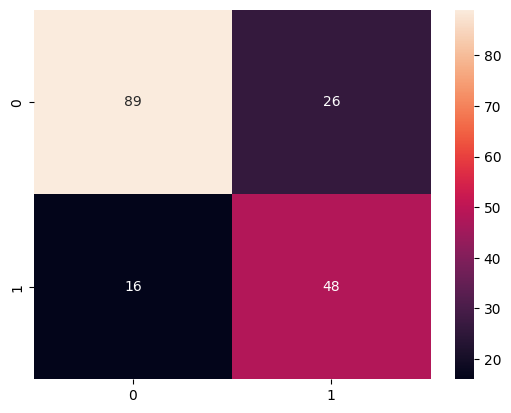

In [64]:
sns.heatmap(cm, annot=True)